In [1]:
# os
import os
import sys
from os.path import join as join_path

# Computations
import numpy as np
import scipy as sp
import sympy as smp

# Science
import CoolProp.CoolProp as CP
import gsw

# System
import yaml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling
import pandas as pd



In [2]:
# Initialization


# Plotting
sns.set_theme()
plt.rcParams['text.usetex'] = True

# Logging
np.set_printoptions(threshold=np.iinfo(np.intp).max)  # Show all elements
np.set_printoptions(linewidth=80)    # Optional: avoid line breaks
jupyter_stdout = sys.stdout
sys.stdout = open("log_wave_maker_theory", "a")

# paths
if __name__ == "__main__":  # Should be run from inside the project!!!
    # project name
    PROJECT_NAME = "ProjectAquarium"

    path = os.getcwd()
    while True:
        if os.path.basename(path) == PROJECT_NAME:
            PROJECT_PATH = path
            break

        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("ProjectAquarium not found")

        path = parent
PATH_FIGURES = "figures"
PATH_DATA = "data"


In [3]:
# aliases
norm = sp.linalg.norm
pi = np.pi

# Indices
XIND = 0
YIND = 1

Z_MAX = 0

# Physical parameters
with open(join_path(PROJECT_PATH, "design", "existing_parts.yaml"), "r") as file:
    aquarium_params = yaml.safe_load(file)["aquarium"]

# aquarium_params
H = aquarium_params["main_box"]["z_inner"] / 1000   # convert to meters
H = H/2     # actual depth of water

In [4]:
# constants (SI)
g0 = sp.constants.g     # At sea level
p0 = sp.constants.atm   # At sea level
T_room = 290            # ~ Israeli winter temperature in Kelvin

seasurface_density = CP.PropsSI('D', 'T', T_room, 'P', p0, 'Water')
viscosity = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water')  # Pa.s
kinematic_viscosity = viscosity / seasurface_density
seawater_surface_tension = 0.074  # N/m, estimate for seawater, +-0.001

# aliases
rho = seasurface_density
mu = viscosity
nu = kinematic_viscosity
tau = seawater_surface_tension


In [5]:
print("density = ", rho, "\nsurface_tension = ", tau)

## complex dispersion == dispersion + damping

In [6]:
# Dispersion relation, capillary-gravity, short waves limit.
def dr_cg_sw(k):
    k = norm(k, axis=-1)
    return np.sqrt((g0 * k + tau/rho * k**3))

In [7]:
N = int(2e3)
k_max = 2*np.pi*int(2e2)
k_ps = np.linspace(k_max/N, k_max, num=N).reshape((N,1))
k_ps_abs = norm(k_ps, axis=-1)

In [8]:
def complex_dispersion(omega, k):
    lhs = (2 - 1j*omega/(nu*k**2))**2 + (k*(g0 + tau/rho * k**2)) / (nu**2 * k**4)
    rhs = 4 * np.sqrt(1 - 1j*omega/(nu*k**2))
    return lhs - rhs

# --- Solver for one k ---
def solve_for_k(k):
    # initial guess: inviscid dispersion relation
    k_abs = norm(k, axis=-1)
    omega0 = np.sqrt(g0*k_abs + tau/rho*k_abs**3)
    # solve numerically
    sol = sp.optimize.newton(func=lambda w: complex_dispersion(w, k_abs), x0=omega0, maxiter=1000, tol=1e-10)
    return sol

omegas = np.array([solve_for_k(k) for k in k_ps])


In [9]:
frequencies = np.real(omegas)/(2*pi)
decay_rates = np.imag(omegas)

In [10]:
# alternative no decay

ks_abs_alt = np.zeros(len(omegas))

for i in range(N):
    f = frequencies[i]
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3)*np.tanh(H*k) - (2*pi*f)**2

    if f < 13.45: 
        k_p_guess = (2*pi*f)**2 / g0
    else:
        k_p_guess = ((2*pi*f)**2 * rho/tau)**(1/3)
    k_lbound = k_p_guess/3
    k_rbound = 3*k_p_guess

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_lbound, k_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")
    ks_abs_alt[i] = sol.root


### dispersion (inverted): wavenumber vs. frequency

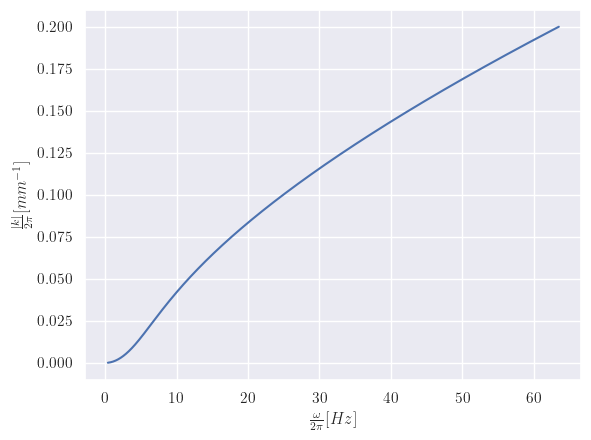

In [34]:
plt.plot(frequencies, norm(k_ps, axis=-1)/(2*np.pi * 1000))
# plt.xlim(0, 50)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 200/100)
plt.ylabel(r"$\frac{|k|}{2\pi} [mm^{-1}]$")

plt.savefig(
    fname=join_path(PATH_FIGURES, "g-c_waves_dispersion.png")
    )

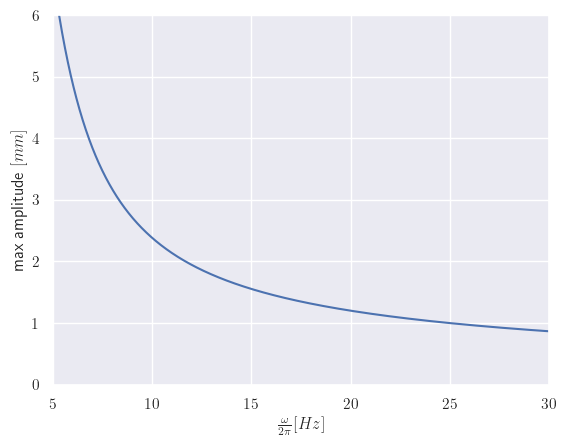

In [40]:
wavelengths = (2*np.pi) / norm(k_ps, axis=-1)
wavelength_to_amplitude = 10


plt.plot(frequencies, wavelengths * 1000/wavelength_to_amplitude)   # mm
plt.xlim(5, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 6)
plt.ylabel(r"max amplitude $[mm]$")

plt.savefig(
    fname=join_path(PATH_FIGURES, "g-c_wavelengths.png")
    )

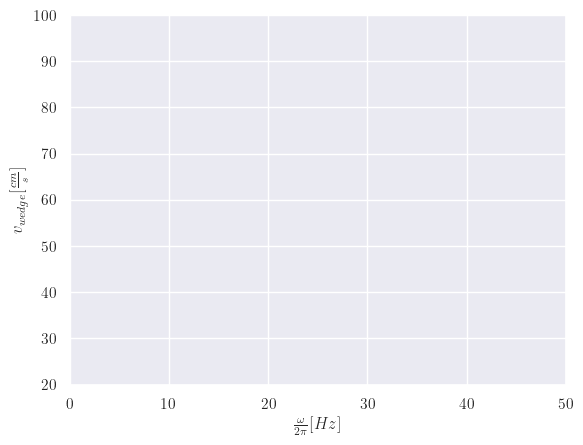

In [13]:
peak_velocity = 2*pi * frequencies * wavelengths / wavelength_to_amplitude 

plt.plot(frequencies, peak_velocity)
plt.xlim(0, 50)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(20, 100)
plt.ylabel(r"$v_{wedge} [\frac{cm}{s}]$")

plt.savefig(fname=join_path(PATH_FIGURES, "wavemaker_peak_velocity.png"))

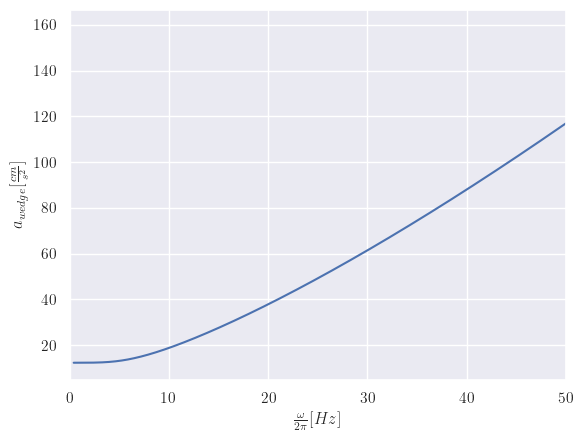

In [14]:
peak_accelaration = (2*pi * frequencies)**2 * wavelengths / wavelength_to_amplitude

plt.plot(frequencies, peak_accelaration)
plt.xlim(0, 50)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(20, 100)
plt.ylabel(r"$a_{wedge} [\frac{cm}{s^2}]$")

plt.savefig(fname=join_path(PATH_FIGURES, "wavemaker_peak_accelaration.png"))

### group velocity vs. frequency

Text(6.393221655171044, 17.832751699173013, '(6.39, 17.83)')

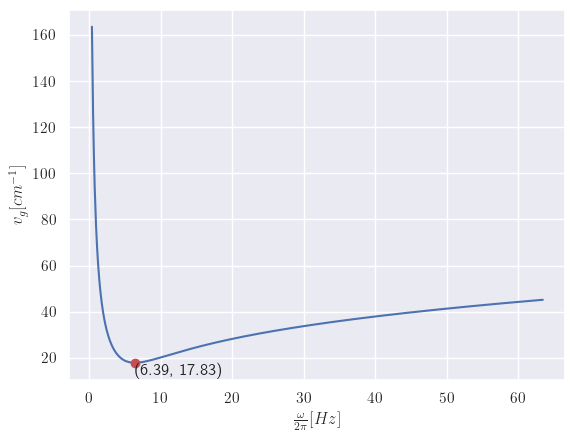

In [15]:
dwdks = np.diff(frequencies)/np.diff(norm(k_ps, axis=-1)/(2*np.pi)/100)
plt.plot(frequencies[:-1], dwdks)
# plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0,0.1)
plt.ylabel(r"$v_g [cm^{-1}]$")
i_min = np.argmin(dwdks)
w_min = frequencies[i_min]
v_min = dwdks[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='top')


### Bond number vs. frequency

Text(0, 0.5, 'tension/gravity contribution ratio')

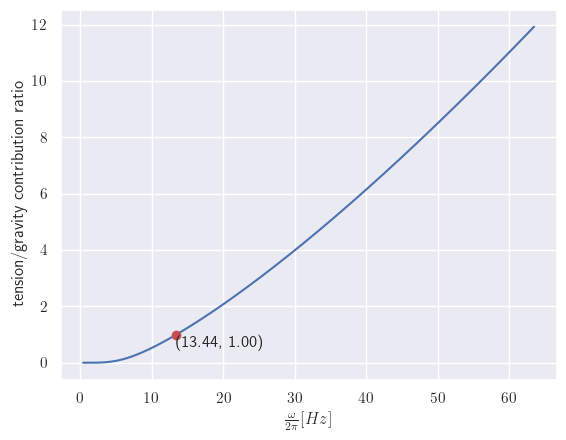

In [16]:
Bo = rho*g0 / (tau * k_ps**2)
plt.plot(frequencies, 1/Bo)
i_equal = np.argmin((Bo-1)**2)
f_equal = frequencies[i_equal]
Bo_equal = Bo[i_equal][0]
print(Bo_equal)
plt.plot([f_equal], [Bo_equal], 'ro')
plt.text(f_equal, Bo_equal, f"({f_equal:.2f}, {Bo_equal:.2f})", fontsize=12, ha='left', va='top')
# plt.xlim(0, 30)
# plt.ylim(0, 4)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension/gravity contribution ratio")

Text(0, 0.5, 'tension - gravity contribution ratio')

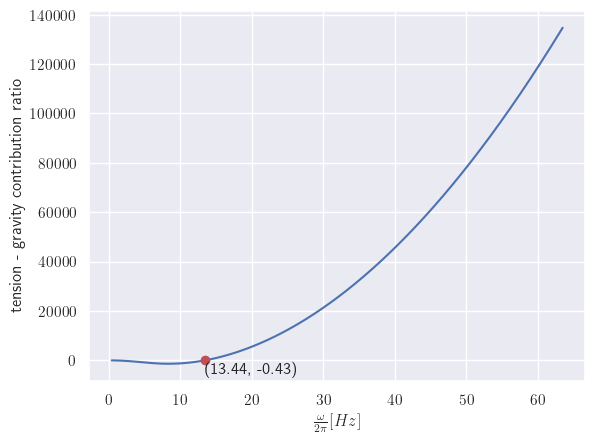

In [17]:
# yet another tension vs gravity comparison graph
c_g_diff = tau/rho * k_ps_abs**3 - g0 * k_ps_abs
plt.plot(frequencies, c_g_diff)
i_equal = np.argmin(c_g_diff[frequencies<20]**2)
f_equal = frequencies[i_equal]
c_g_diff_equal = c_g_diff[i_equal]
plt.plot([f_equal], [c_g_diff_equal], 'ro')
plt.text(f_equal, c_g_diff_equal, f"({f_equal:.2f}, {c_g_diff_equal:.2f})", fontsize=12, ha='left', va='top')
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension - gravity contribution ratio")

### phase velocity vs frequency

Text(0, 0.5, '$v_{phase}[ms^{-1}]$')

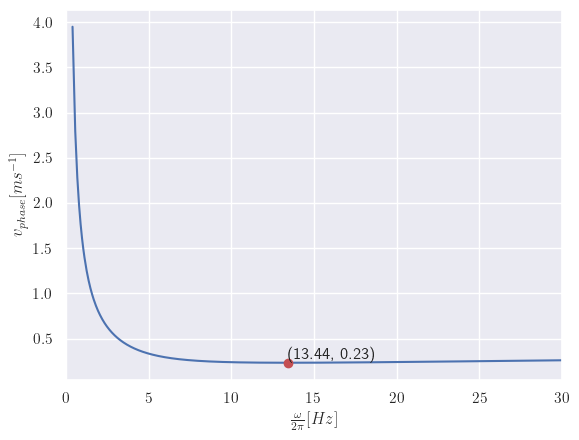

In [18]:
N = int(1e3)
k_max = 2*np.pi*int(1e3)
vs = np.real(omegas)/norm(k_ps, axis=-1)
plt.plot(frequencies, vs)

i_min = np.argmin(vs)
w_min = frequencies[i_min]
v_min = vs[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='bottom')

plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 120/100)
plt.ylabel(r"$v_{phase}[ms^{-1}]$")

### decay rate vs. frequency

Text(0, 0.5, '$\\alpha \\left[s^{-1}\\right]$')

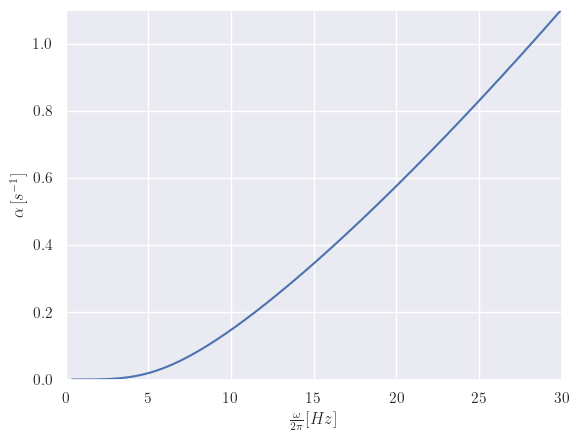

In [19]:
plt.plot(np.real(omegas)/(2*np.pi), -np.imag(omegas))
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 1.1)
plt.ylabel(r"$\alpha \left[s^{-1}\right]$")

# Wave making theory

### evanescent modes

Text(0.5, 0, 'wavenumber $[cm^{-1}]$')

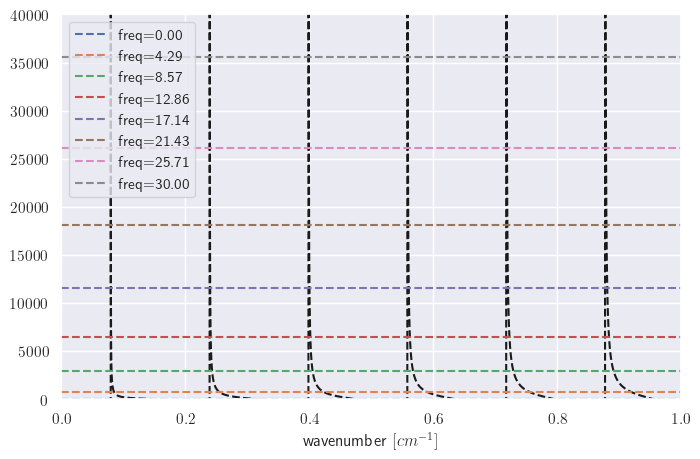

In [20]:
n_dense = int(1e5)
k_max = 2*np.pi*int(1e2) # m^-1
ks_dense = np.linspace(k_max/n_dense, k_max, num=n_dense).reshape((n_dense,1))
f_max = 30  # Hz


plt.figure(figsize=(8,5))

ks_dense_abs = norm(ks_dense, axis=-1)
plt.plot(
    ks_dense_abs/100,   # cm^-1
    (tau/rho * ks_dense_abs**3 - g0*ks_dense_abs)*np.tan(ks_dense_abs*H),
    '--k')

df = frequencies[-1]/n_dense
N = 8
freqs = np.linspace(df, f_max, num=N)
for i in range(N):
    freq = freqs[i]
    k = ks_dense_abs[i]
    plt.plot([0, k_max], [(2*pi*freq)**2]*2, '--', label=fr"freq={freq:.2f}")
# label=fr"$f_p = {freq:.2f}Hz$"
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 4e4)
plt.xlabel(r"wavenumber $[cm^{-1}]$")

This seems to mean that 30cm away from the wave maker, all but the first
evanescent mode disappear. E.g. the second mode has $k \approx 0.12cm^{-1}$, so 
$k \cdot 30cm \approx 3.6$, which means that the mode decayed by a factor of
$e^{-3.6} \approx 2\%$ of the original amplitude. The first mode, on the other 
hand, seems to be at $k \approx 0.04cm^{-1}$ and so $k \cdot 30cm \approx 1.2$, 
which is still dominant with $70\%$ amplitude loss. The traveling mode, on the
other hand, say at the transition point with $\frac{\omega}{2 \pi} = 13.47Hz$ 
and $v_{phase} \approx 23\frac{cm}{s}$ has $\alpha \approx 0.3s^{-1}$, which 
means that at $30cm$ it has lost about $33\%$ of its amplitude, which is not too
bad. At $20Hz$, on the other hand, $\alpha \approx 0.6$ and the mode lost 
$\approx 50\%$ of its initial amplitude.

## mode amplitude distribution

variables: \omega_p, \alpha, d, S, M, N
parameters: h=H
remark: I do *not* normalize the height by H, so z is expected to be in the
range -H to 0.
remark: we work in the deep water limit, so tanh(h k_p) is dropped in the
expression for the dispersion (computation of k_p), and cosh(k_p (h + z)),
sinh(z (h + z)) are replaced with e^{k_p (h + z)} in compuing the travelin part 
of the velocity potential expression. I also extract e^{-h K_p} from A_p, 
A_{e,s}, for numerics sake.

In [21]:
def get_transition_point(rho=seasurface_density, tau=seawater_surface_tension):
    return np.sqrt(rho*g0/tau)

In [22]:
def alpha_func(z, d, alpha, h=H):
    """
    Piecewise alpha function.
    """
    z = np.asarray(z)
    a_per_z = np.empty_like(z, dtype=float)
    mask1 = (-d <= z) & (z <= 0)
    mask2 = (-h <= z) & (z < -d)

    a_per_z[mask1] = alpha
    a_per_z[mask2] = 0

    if not np.all(mask1 | mask2):
        raise ValueError("z out of range")
    
    return a_per_z.item() if np.isscalar(z) else a_per_z

# Propagating wave number k_p
def get_kp(w_p, tau=seawater_surface_tension):
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3) - w_p**2
    
    k_p_guess = w_p**2 / g0
    k_p_lbound = 0
    k_p_rbound = 1e4

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_p_lbound, k_p_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")

    return sol.root

# Evanescent modes k_{s,n}
def get_k_ns(N, w_p, rho=seasurface_density, tau=seawater_surface_tension, h=H):
    def decay_kn(k):
        return (-g0*k + (tau/rho)*k**3)*np.tan(k*h) - w_p**2

    k_equal = get_transition_point(rho, tau)
    k_ns = np.zeros(N)
    
    for n in range(1, N+1):
        # Approx first guess
        delta = pi / (4*h)
        if (n-1/2)*pi/h < k_equal:
            k_guess = (n-1/4)*np.pi/h   # tan is decreasing to the right
            k_lbound  = k_guess - delta * (1-1e-3)
            k_rbound = k_guess + delta * (1+1e-3) 
        else:
            k_guess = (n-3/4)*np.pi/h   # tan is decreasing to the left
            k_lbound  = k_guess - delta * (1+1e-3)
            k_rbound = k_guess + delta * (1-1e-3) 
                
        # print(k_lbound, k_rbound)
        # print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
        # print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

        # find 0
        sol = sp.optimize.root_scalar(
            decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
            )
        
        # error checking
        if not sol.converged:
            raise RuntimeError(f"Root not found for n={n}")
        
        k_ns[n-1] = sol.root
        
    return k_ns

def B_m0(z_ms, k_p, a, d, h=H):
    return k_p/2 * (
            - np.tan(a) * (np.exp(k_p * z_ms) - np.exp(-k_p * (z_ms + 2*h)))
            + 1j * (np.exp(k_p * z_ms) + np.exp(-k_p * (z_ms + 2*h)))
        ) * np.exp(
            1j * k_p * np.tan(a) * (d + z_ms)
        )

def B_mn(z_m, k_n, a, d, h=H):
    return -k_n * (
        np.cos(k_n * h * (1 + z_m/h)) 
        - np.tan(a) * np.sin(k_n * (h + z_m))
    ) * np.exp(-k_n * np.tan(a) * (d + z_m))

def get_zs(M, z_min=-H, z_max=0):
    zs = np.flip(np.linspace(z_min, z_max, M))
    return zs

def construct_B(z_ms, k_p, k_ns, alpha, d, h=H):
    ks_mesh, zs_mesh = np.meshgrid(k_ns, z_ms)
    a = alpha_func(z_ms, d, alpha)
    a_mesh = alpha_func(zs_mesh, d, alpha, h=H)
    B = np.zeros([len(z_ms), 1+len(k_ns)], dtype='complex')
    B[:,0] = B_m0(z_ms, k_p, a, d, h)
    B[:,1:] = B_mn(zs_mesh, ks_mesh, a_mesh, d, h)
    return B

def construct_D(z_ms, w_p, S, d, alpha, h=H):
    a = alpha_func(z_ms, d, alpha, h=h)
    return - S * w_p * np.tan(a)

def compute_A_exact(
        M:int, N: int,                                      # Numerical variables
        f_p:float, S:float, d: float,                       # Physical variables
        rho=seasurface_density, tau=seawater_surface_tension,
                                                            # Physical params
        alpha=pi/6, h=H,                                    # Setting params
        eps=1e-12                                           # Numerical params
        ):
    w_p = 2*pi*f_p
    z_ms = get_zs(M, z_min=-h, z_max=0)
    k_p = get_kp(w_p)
    k_ns = get_k_ns(N, w_p, rho, tau)
    # print(np.exp(k_p * (z_ms))[-1])
    z_ms = z_ms[np.exp(k_p * (z_ms-np.max(z_ms))) > eps]    # Truncate z_ms
    M = len(z_ms)                                           # Update M
    B = construct_B(z_ms, k_p, k_ns, alpha=alpha, d=d, h=h)
    D = construct_D(z_ms, w_p=w_p, S=S, d=d, alpha=alpha)
    A, res, rank, s = np.linalg.lstsq(B, D, rcond=None)
    A_df = pd.DataFrame(A)
    A_df.to_pickle(join_path(
        ".", PATH_DATA,
        f"A_vp_{M}_{N}_{f_p:.2g}_{S:.2g}_{d:.2g}_{eps:.2g}.pkl"))
    return A



In [27]:
stroke = 2e-3       # meters
mean_depth = 2e-3   # meters
f_plunger = 20    # Hz
w_plunger = 2*pi*f_plunger
wedge_tip_angle = pi/6
k_p = get_kp(2*pi*f_plunger)
eps = 1e-46

### convergence in vertical sample density

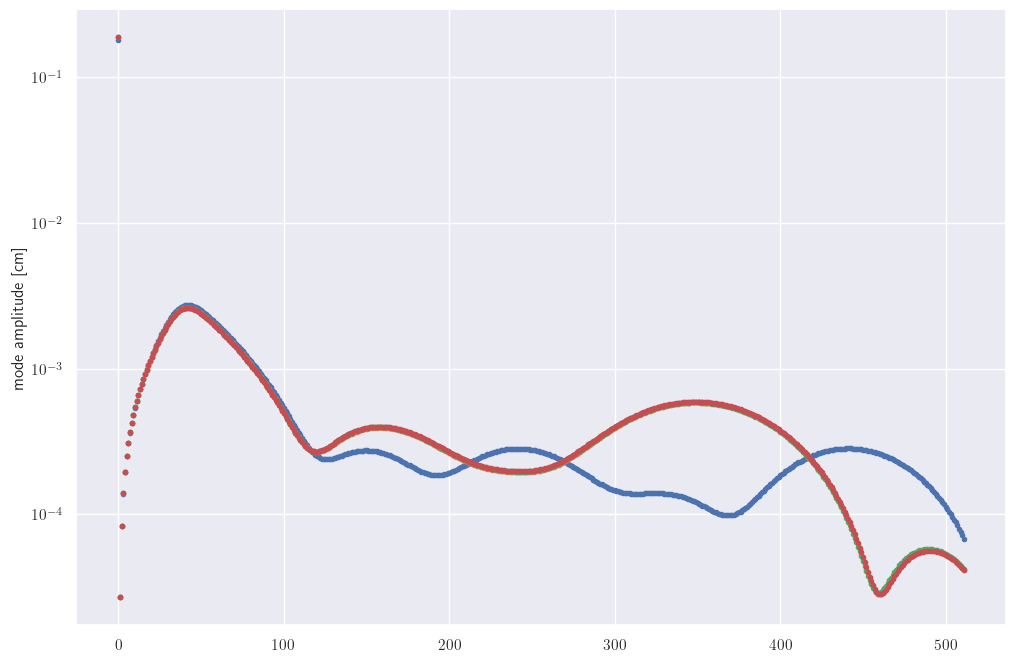

In [28]:
# Clear log:
open("log_wave_maker_theory", "w").close()

# Different vertical sample density for same total mode number:
plt.figure(figsize=(12,8))
N = 511
for M in [1e3, 1e4, 1e5, 4e5]:   

    k_ns_dense = get_k_ns(N, w_plunger)
    ks_dense = np.concatenate(([k_p], k_ns_dense))

    A_dense = compute_A_exact(
        M=int(M), N=N,
        f_p=f_plunger, S=stroke, d=mean_depth,
        alpha=wedge_tip_angle, h=H,
        eps=1e-46
        )
    mode_amplitudes_dense = np.abs(1j*(ks_dense/w_plunger)*A_dense)  # value in m

    plt.semilogy(mode_amplitudes_dense * 1e2, '.')   # print in cm.

    plt.ylabel(r"mode amplitude [cm]")
plt.savefig(join_path(
    PATH_FIGURES,
    f"mode_mag_{N}__{f_plunger:.2g}_{stroke:.2g}_{mean_depth:.2g}_{eps:.2g}.png"
    ))

### 

### convergence in number of modes

### 

In [29]:
# Clear log:
open("log_wave_maker_theory", "w").close()

M = 4e4
mode_amplitudes_dense = {}

# Differentvertical sample density for same total mode number:
plt.figure(figsize=(12,8))
for N in [127, 255, 511, 1023, 2047, 4095]:
    print(f"N = {N}", flush=True)
    k_ns_dense = get_k_ns(N, w_plunger)
    ks_dense = np.concatenate(([k_p], k_ns_dense))

    A_dense = compute_A_exact(
        M=int(M), N=N,
        f_p=f_plunger, S=stroke, d=mean_depth,
        alpha=wedge_tip_angle, h=H,
        eps=1e-46
        )

    mode_amplitudes_dense[N] = np.abs(1j*(ks_dense/w_plunger)*A_dense)  # value in m

<Figure size 1200x800 with 0 Axes>

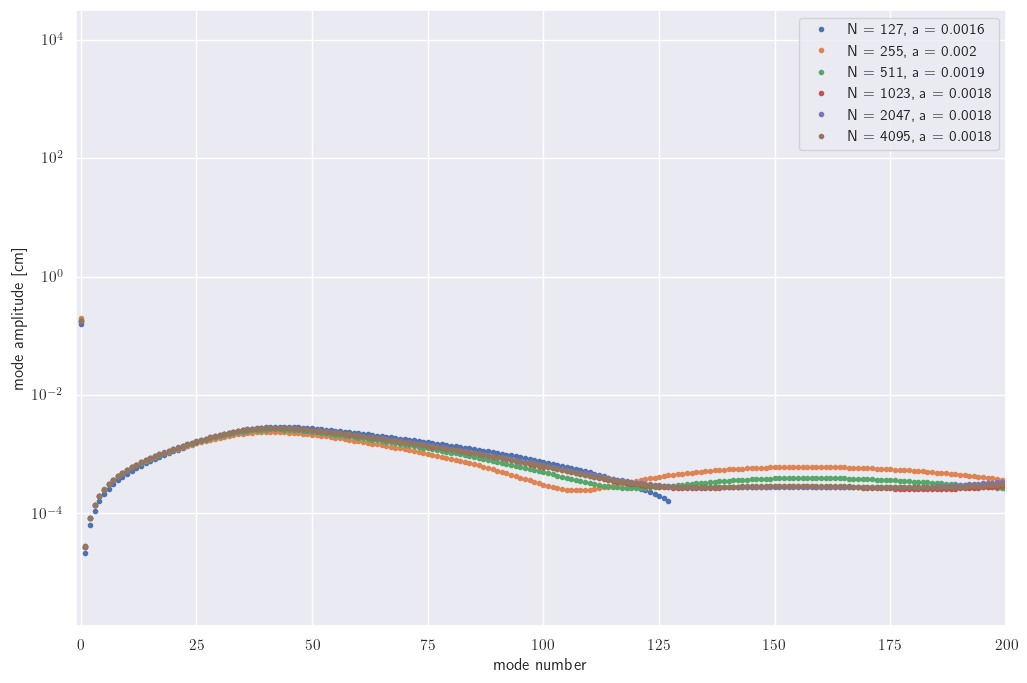

In [30]:
plt.figure(figsize=(12,8))
for N in [127, 255, 511, 1023, 2047, 4095]:
    a = mode_amplitudes_dense[N][0]
    plt.semilogy(
        mode_amplitudes_dense[N] * 1e2, '.', label=f"N = {N}, a = {a:.2g}"
        )   # print in cm.

    plt.legend()
    plt.xlabel(r"mode number")
    plt.ylabel(r"mode amplitude [cm]")
    plt.xlim(-1, 200)
plt.savefig(join_path(
    PATH_FIGURES,
    f"mode_mag_{M:.2g}_127-4095_{f_plunger:.2g}_{stroke:.2g}_{mean_depth:.2g}_{eps:.2g}.png"
    ))    

In [46]:
mode_amplitudes_dense[4095]

array([1.60274833e-03, 6.30131306e-07, 1.88229182e-06, 3.11384416e-06,
       4.31247754e-06, 5.46781836e-06, 6.57187679e-06, 7.61924371e-06,
       8.60707862e-06, 9.53489614e-06, 1.04042692e-05, 1.12184747e-05,
       1.19821360e-05, 1.27008706e-05, 1.33809641e-05, 1.40290860e-05,
       1.46519698e-05, 1.52560068e-05, 1.58467574e-05, 1.64282417e-05,
       1.70019813e-05, 1.75657545e-05, 1.81122171e-05, 1.86276896e-05,
       1.90917721e-05, 1.94786665e-05, 1.97608429e-05, 1.99148631e-05,
       1.99277353e-05, 1.98011675e-05, 1.95516293e-05, 1.92061629e-05,
       1.87959882e-05, 1.83505634e-05, 1.78938207e-05, 1.74428565e-05,
       1.70083644e-05, 1.65959577e-05, 1.62076388e-05, 1.58430989e-05,
       1.55007008e-05, 1.51781573e-05, 1.48729508e-05, 1.45826086e-05,
       1.43048236e-05, 1.40375300e-05, 1.37789198e-05, 1.35274328e-05,
       1.32817403e-05, 1.30407235e-05, 1.28034423e-05, 1.25691146e-05,
       1.23370939e-05, 1.21068543e-05, 1.18779549e-05, 1.16500471e-05,
      

In [31]:
# compare to Wu's paper

A_p = A_dense[0]
a_p = mode_amplitudes_dense[4095][0]
A_p_Wu = A_p / (w_plunger * stroke * H)
ratio_Wu = np.abs(-1j * A_p_Wu * k_p * H)

sys.stdout = open("log_wave_maker_theory", "a")
print(f"A_p = {A_p:.2g}\ntraveling_mode_amplitude = {a_p:.2g}")
print(f"A_p_Wu = {A_p_Wu:.2g}\namplitude_Wu/S = {ratio_Wu:.2g}")
print(f"    compare\ntraveling_mode_amplitude/S = {a_p/stroke:.2g}")


In [32]:
omega = solve_for_k([k_p])

x_30cm = 0.3     # m
k_ns = get_k_ns(N, w_plunger)
a_30cm = np.zeros(N)
for n in range(N):
    a_30cm[n] = np.abs(
        1j*(k_p/w_plunger)*A_dense[0] * 1/2 * (1 + np.exp(-2*k_p*H)) * np.exp(1j*k_p*x_30cm)
            * np.exp(-np.abs(np.imag(omega) * k_p/np.real(omega) * x_30cm))
        + np.sum(1j*(k_ns[:n]/w_plunger)*A_dense[1:n+1] * np.cos(k_ns[:n]*H) * np.exp(-k_ns[:n]*x_30cm))
    )

In [33]:
k_p/np.real(omega)

np.float64(4.169749770462706)

In [78]:
np.exp(np.imag(omega) * k_p/np.real(omega) * x_30cm)

np.float64(0.8305570893492669)

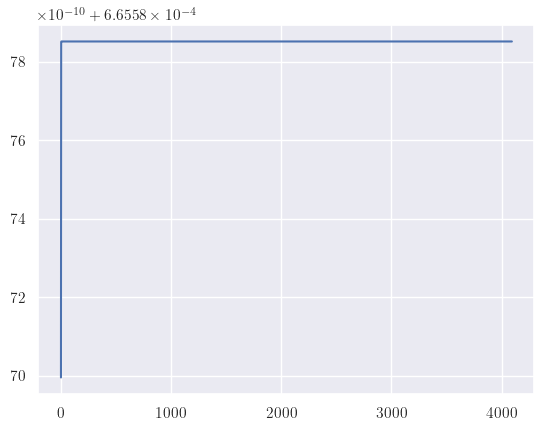

In [79]:
plt.plot(a_30cm)
# plt.xlim(0,5)

## archive


In [ ]:
# Example usage
B0 = B_m0(k_p, H, z_m, alpha_val, d)
Bn = B_mn(k_s_n, H, z_m, alpha_val, d)
D = D_m(S, omega_p, z_m, d, alpha_val)

# Amplitudes
A0 = A_p = 1.0
An = A_s_n = 0.5

In [ ]:
def dispersion_kp(k):
    return (g0*k + (tau/rho)*k**3)*np.tanh(k*H) - w_plunger**2

k_p_guess = w_plunger**2 / g0
delta = pi / (4*h) * (1-1e-3)
    k_lbound  = k_p_guess - delta
    k_rbound = k_p_guess + delta
    # print(k_lbound, k_rbound)
    # print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
    # print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

    # find 0
    sol = sp.optimize.root_scalar(
        decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
        )
k_p = sp.optimize.fsolve(dispersion_kp, x0=k_p_guess)[0]
g0*k*np.tanh(k_p*H) + (tau/rho)*k_p**3 - w_plunger**2

np.float64(-5137.218744908463)